In [1]:

from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain.messages import RemoveMessage

In [2]:
load_dotenv()

True

In [3]:
model = init_chat_model("google_genai:gemini-2.5-flash-lite")

In [4]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [6]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [7]:
graph = builder.compile(checkpointer=InMemorySaver())

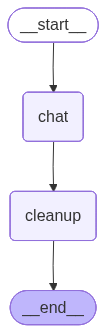

In [8]:
graph

In [9]:
config = {"configurable": {"thread_id": "t1"}}

In [11]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Tanish"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [AIMessage(content='Hi Tanish, let\'s talk about **LangChain**!\n\nLangChain is a popular **framework for developing applications powered by large language models (LLMs)**. Think of it as a toolkit that makes it easier to build complex and sophisticated LLM-powered applications by providing a standardized way to connect LLMs with other components.\n\n**The Core Problem LangChain Solves:**\n\nLLMs are incredibly powerful for generating text, answering questions, and understanding language. However, using them effectively in real-world applications often requires more than just a single LLM call. You typically need to:\n\n*   **Connect to Data Sources:** LLMs are trained on massive datasets, but they don\'t have real-time access to your specific documents, databases, or the internet.\n*   **Interact with Tools:** LLMs can\'t inherently browse the web, perform calculations, or interact with APIs.\n*   **Maintain Context:** For conversational agents, remembering previous turns

In [12]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 7
